<a href="https://colab.research.google.com/github/MHKayahan/Veri-Bilimine-Giris-2025-2026-Proje--Website-Phishing-/blob/main/src/VeriBilimineGirisProje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


   MODEL DOĞRULUK ORANLARI (Optimize Öncesi)
  Karar Ağacı                  → 0.8782
  Rastgele Orman               → 0.8782
  K-En Yakın Komşu             → 0.8561
  Basit Bayes                  → 0.8118
  Lojistik Regresyon           → 0.8339
  Yapay Sinir Ağı (YSA)        → 0.8708


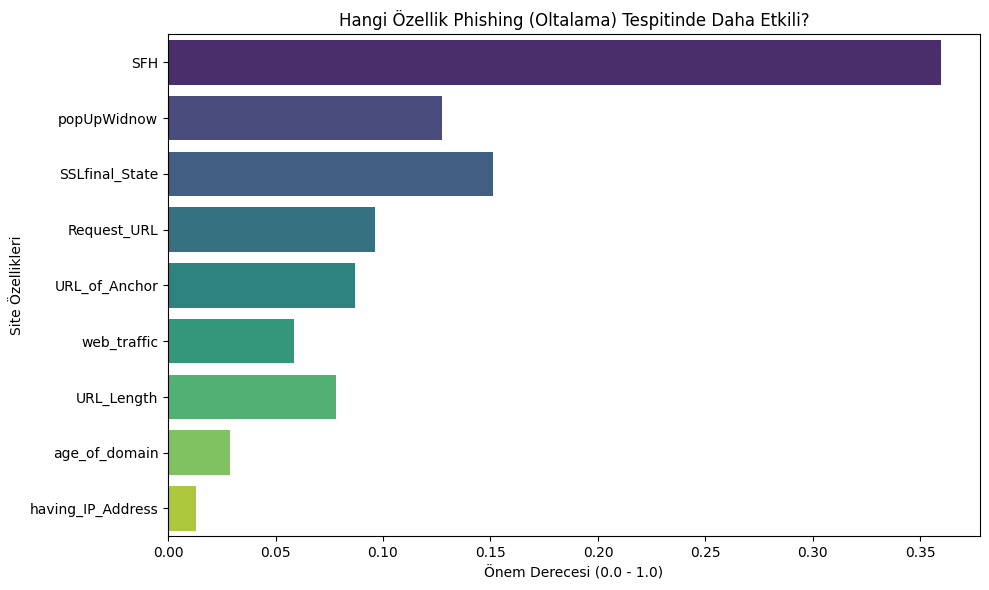


   RASTGELE ORMAN İÇİN İNCE AYAR (RandomizedSearchCV)

  [Referans] Default RF Doğruluk: 0.8782

En iyi ayarlar aranıyor (50 kombinasyon × 5-fold CV)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

  Bulunan En İyi Parametreler : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}
  Default RF Doğruluk         : 0.8782
  Optimize Edilmiş Doğruluk   : 0.9004
  Kazanım                     : +0.0221

Veri Setinin İlk 5 Satırı:
   SFH  popUpWidnow  SSLfinal_State  Request_URL  URL_of_Anchor  web_traffic  \
0    1           -1               1           -1             -1            1   
1   -1           -1              -1           -1             -1            0   
2    1           -1               0            0             -1            0   
3    1            0               1           -1             -1            0   
4   -1           -1               1           -1              0            0   

   URL_Length  a

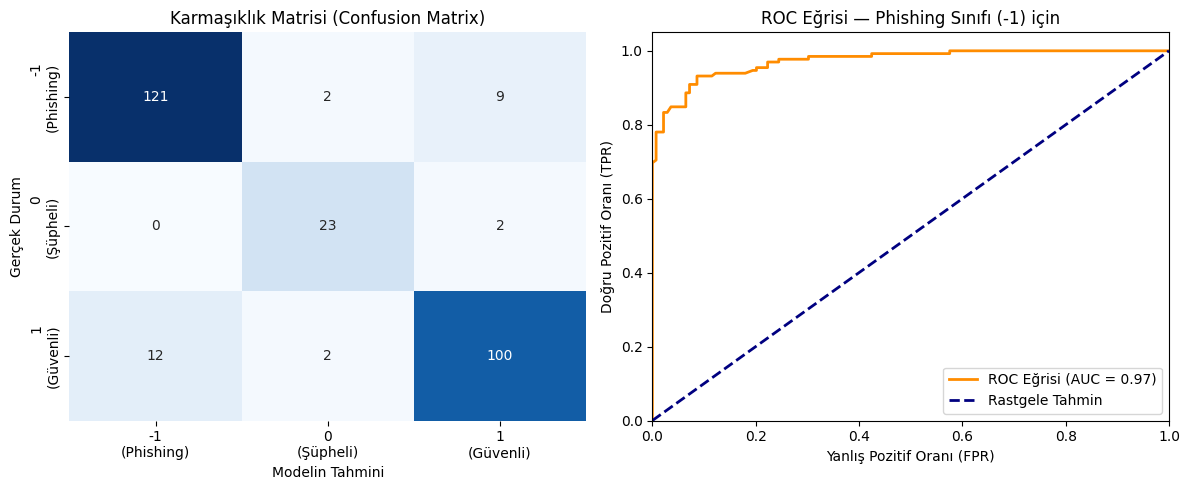

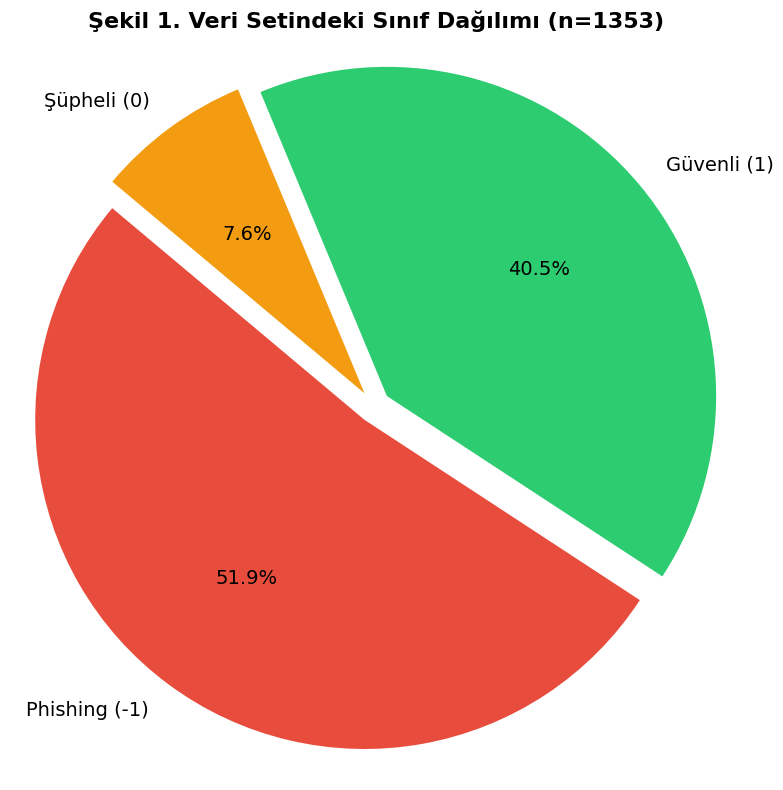

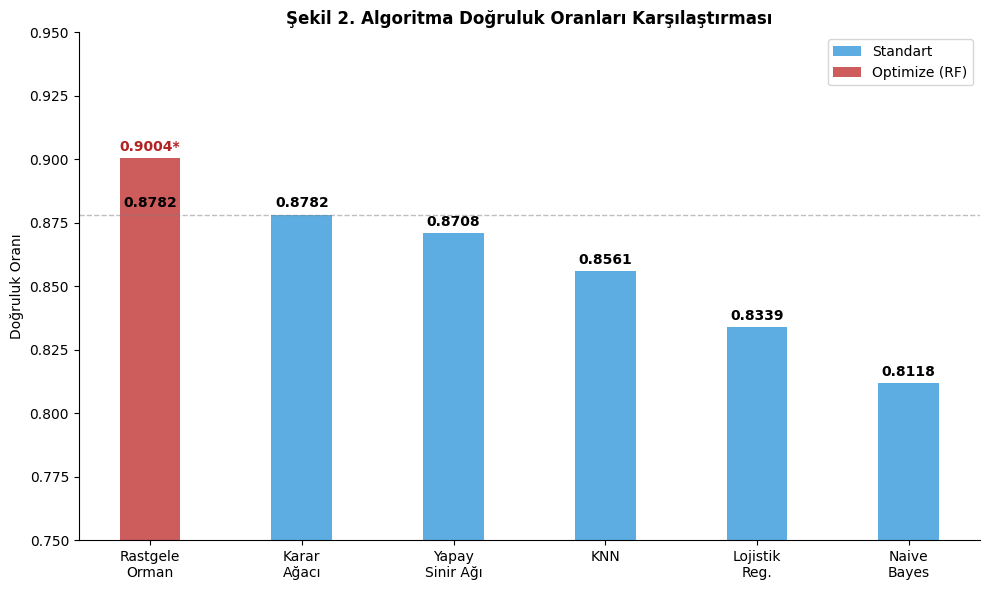

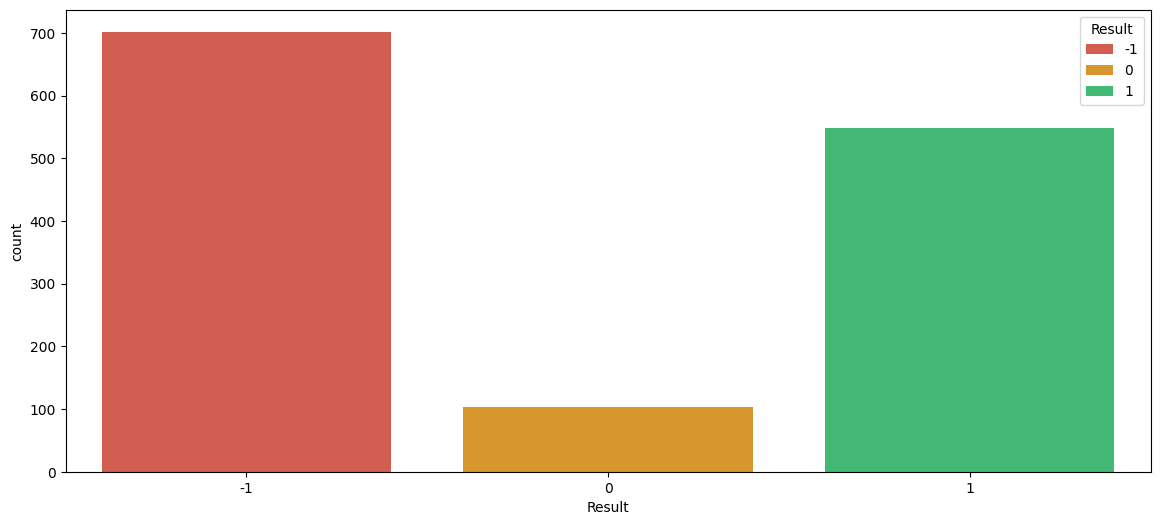

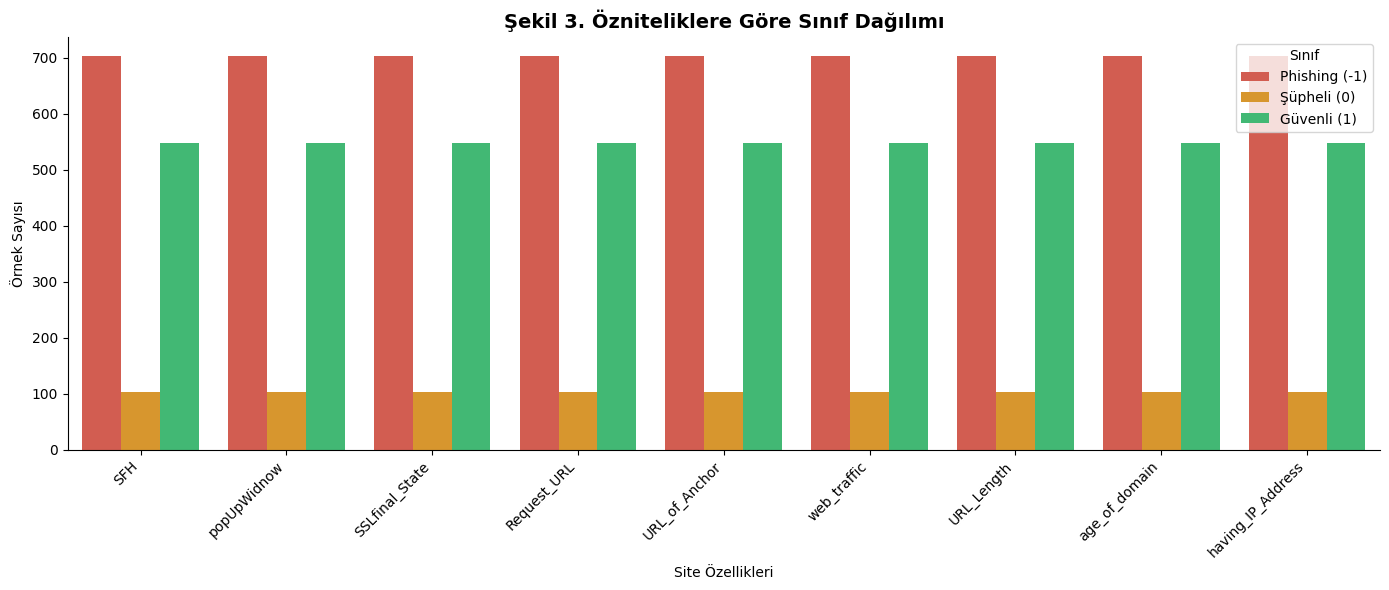

In [1]:
from scipy.io import arff
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#  ARFF Dosyasını Yükleme
data, meta = arff.loadarff('PhishingData.arff')

# Veriyi Pandas DataFrame'ine Dönüştürme
df = pd.DataFrame(data)

# Veri Tiplerini Düzeltme
for col in df.columns:
    if pd.api.types.is_object_dtype(df[col]):
        df[col] = df[col].str.decode('utf-8').astype(int)

# Özellikler (X) ve Hedef Değişken (y) Ayrımı
X = df.drop('Result', axis=1)
y = df['Result']

# Veriyi Eğitim (%80) ve Test (%20) Olarak Ayırma
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  MODELLERİ TANIMLAMA VE EĞİTME
models = {
    "Karar Ağacı":          DecisionTreeClassifier(random_state=42),
    "Rastgele Orman":       RandomForestClassifier(random_state=42),
    "K-En Yakın Komşu":    KNeighborsClassifier(),
    "Basit Bayes":          GaussianNB(),
    "Lojistik Regresyon":   LogisticRegression(max_iter=1000, random_state=42),
    "Yapay Sinir Ağı (YSA)": MLPClassifier(
                                hidden_layer_sizes=(100,),
                                max_iter=1000,
                                random_state=42
                             ),
}

print("\n" + "="*50)
print("   MODEL DOĞRULUK ORANLARI (Optimize Öncesi)")
print("="*50)
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"  {name:<28} → {accuracy:.4f}")


#  ÖZELLİK ÖNEM DERECESİ GRAFİĞİ
rf_model = models["Rastgele Orman"]
feature_importances = rf_model.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(
    x=feature_importances,
    y=X.columns,
    palette="viridis",
    hue=X.columns,
    legend=False
)
plt.title('Hangi Özellik Phishing (Oltalama) Tespitinde Daha Etkili?')
plt.xlabel('Önem Derecesi (0.0 - 1.0)')
plt.ylabel('Site Özellikleri')
plt.tight_layout()
plt.show()

#  HİPERPARAMETRE OPTİMİZASYONU — RandomizedSearchCV
print("\n" + "="*50)
print("   RASTGELE ORMAN İÇİN İNCE AYAR (RandomizedSearchCV)")
print("="*50)

default_acc = accuracy_score(y_test, rf_model.predict(X_test))
print(f"\n  [Referans] Default RF Doğruluk: {default_acc:.4f}")

param_dist = {
    'n_estimators':      [50, 100, 200, 300, 500],
    'max_depth':         [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\nEn iyi ayarlar aranıyor (50 kombinasyon × 5-fold CV)...")
rf_random.fit(X_train, y_train)

best_rf_model = rf_random.best_estimator_
optimized_predictions = best_rf_model.predict(X_test)
optimized_accuracy = accuracy_score(y_test, optimized_predictions)

print(f"\n  Bulunan En İyi Parametreler : {rf_random.best_params_}")
print(f"  Default RF Doğruluk         : {default_acc:.4f}")
print(f"  Optimize Edilmiş Doğruluk   : {optimized_accuracy:.4f}")
print(f"  Kazanım                     : {(optimized_accuracy - default_acc):+.4f}")

#  VERİ SETİNİN İLK 5 SATIRI
print("\nVeri Setinin İlk 5 Satırı:")
print(df.head())

#  SENTETİK VERİ TESTİ
print("\n" + "="*50)
print("   SENTETİK VERİ TESTİ")
print("="*50)

sentetik_veriler = [
    [-1, -1, -1, -1, -1, -1, -1, -1, -1],  # Tüm özellikler phishing sinyali
    [ 1,  1,  1,  1,  1,  1,  1,  1,  1],  # Tüm özellikler güvenli sinyali
    [ 1, -1, -1,  1,  0, -1,  1,  1,  0],  # Karışık
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0],  # Hepsi şüpheli
    [ 1,  1, -1,  1,  1,  1,  1,  1,  1],  # Büyük çoğunluk güvenli sinyali
]

etiket_map = {-1: "PHİSHİNG (Tehlikeli)", 0: "ŞÜPHELİ", 1: "GÜVENLİ"}

sentetik_df = pd.DataFrame(sentetik_veriler, columns=X.columns)
sentetik_tahminler = best_rf_model.predict(sentetik_df)

print("\nSentetik Siteler İçin Tahminler:")
for i, tahmin in enumerate(sentetik_tahminler):
    sonuc = etiket_map[tahmin]
    print(f"  {i+1}. Senaryo: {sonuc}  (ham değer={tahmin})")

#  KARMAŞIKLIK MATRİSİ + ROC EĞRİSİ
plt.figure(figsize=(12, 5))

# ── Sol: Confusion Matrix
#Eksende -1, 0, 1 göster (sklearn otomatik 0,1,2 yazar)
plt.subplot(1, 2, 1)
classes_sorted = sorted(best_rf_model.classes_)  # [-1, 0, 1]
cm = confusion_matrix(y_test, optimized_predictions, labels=classes_sorted)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[f"{c}\n({'Phishing' if c==-1 else 'Şüpheli' if c==0 else 'Güvenli'})" for c in classes_sorted],
    yticklabels=[f"{c}\n({'Phishing' if c==-1 else 'Şüpheli' if c==0 else 'Güvenli'})" for c in classes_sorted]
)
plt.title("Karmaşıklık Matrisi (Confusion Matrix)")
plt.xlabel("Modelin Tahmini")
plt.ylabel("Gerçek Durum")

# ── Sağ: ROC Eğrisi — Phishing sınıfı (-1) için
plt.subplot(1, 2, 2)

classes = list(best_rf_model.classes_)
#Hedef sınıf -1 (Phishing)
target_class = -1 if -1 in classes else classes[0]
target_idx   = classes.index(target_class)

y_prob        = best_rf_model.predict_proba(X_test)[:, target_idx]
y_test_binary = (y_test == target_class).astype(int)

fpr, tpr, _ = roc_curve(y_test_binary, y_prob)
roc_auc     = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Eğrisi (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Rastgele Tahmin')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.ylabel('Doğru Pozitif Oranı (TPR)')
plt.title('ROC Eğrisi — Phishing Sınıfı (-1) için')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()



# Sınıf dağılımını hesapla
class_counts = df['Result'].value_counts()

# Renkler ve etiketler
labels = ['Phishing (-1)', 'Güvenli (1)', 'Şüpheli (0)']
# Veri setindeki dağılıma göre eşleştirildi (en çoktan en aza)
sizes = [class_counts[-1], class_counts[1], class_counts[0]]
colors = ['#e74c3c', '#2ecc71', '#f39c12']
explode = (0.05, 0.05, 0.05)  # Dilimleri birbirinden hafifçe ayırmak için

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=False, startangle=140,
        textprops={'fontsize': 14})

plt.title('Şekil 1. Veri Setindeki Sınıf Dağılımı (n=1353)', fontweight='bold', fontsize=16)
plt.axis('equal')  # Tam bir daire olmasını sağlar
plt.tight_layout()
# plt.savefig('sekil_1_sinif_dagilimi.png', dpi=300)
plt.show()

# Model İsimleri ve Doğruluk Oranları
model_names = ['Rastgele\nOrman', 'Karar\nAğacı', 'Yapay\nSinir Ağı', 'KNN', 'Lojistik\nReg.', 'Naive\nBayes']
standart_acc = [0.8782, 0.8782, 0.8708, 0.8561, 0.8339, 0.8118]
# Sadece Rastgele Orman'ın optimize edilmiş değeri var
optimize_acc = [0.9004, 0, 0, 0, 0, 0]

x = np.arange(len(model_names))  # X ekseni etiket yerleşimleri
width = 0.4  # Sütun genişliği

fig, ax = plt.subplots(figsize=(10, 6))

# Standart oranlar için mavi sütunlar
rects1 = ax.bar(x, standart_acc, width, label='Standart', color='#5DADE2')

# Rastgele Orman'ın optimize edilmiş oranı için kırmızı sütun
rects2 = ax.bar(x[0], optimize_acc[0], width, label='Optimize (RF)', color='#CD5C5C')

# Grafiğe metin, etiketler ve başlık ekleme
ax.set_ylabel('Doğruluk Oranı')
ax.set_title('Şekil 2. Algoritma Doğruluk Oranları Karşılaştırması', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim([0.75, 0.95]) # Y ekseni sınırlarını belirle
ax.legend()

# Değerleri sütunların üzerine yazdırma
for rect in rects1:
    height = rect.get_height()
    if height > 0: # 0 olanları yazdırma
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puan dikey ofset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

# Optimize edilmiş RF değerini yazdırma
ax.annotate(f'{optimize_acc[0]:.4f}*',
            xy=(rects2[0].get_x() + rects2[0].get_width() / 2, optimize_acc[0]),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center', va='bottom', color='#B22222', fontweight='bold')

# Y ekseni limitini görsel olarak hizalamak için referans çizgisi
ax.axhline(y=0.8782, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Çerçeveyi (spines) düzenleme (sağ ve üst çizgileri kaldırma)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig('sekil_2_algoritma_karsilastirmasi.png', dpi=300)
plt.show()

# Veri setindeki özellikleri listele (Result dışındakiler)
features = [col for col in df.columns if col != 'Result']

# Görselleştirme için renk paleti (Phishing: Kırmızı, Şüpheli: Turuncu, Güvenli: Yeşil)
custom_palette = {-1: "#e74c3c", 0: "#f39c12", 1: "#2ecc71"}

plt.figure(figsize=(14, 6))

# Countplot oluştur
ax = sns.countplot(data=df, x='Result', hue='Result', palette=custom_palette) # Seaborn x ve hue parametrelerini aynı istiyor.
# x ekseni için bir feature seçmemiz lazım.
# İsteğine uygun olarak veriyi 'melt' edip tek bir grafikte göstermek daha doğru.

# Veriyi görselleştirmeye uygun formata getirme (Melt işlemi)
df_melted = df.melt(id_vars=['Result'], value_vars=features, var_name='Özellik', value_name='Değer')

plt.figure(figsize=(14, 6))
# seaborn countplot ile her bir özellik için -1, 0 ve 1 değerlerinin frekansını çizdirme
sns.countplot(data=df_melted, x='Özellik', hue='Result', palette=custom_palette)

plt.title('Şekil 3. Özniteliklere Göre Sınıf Dağılımı', fontweight='bold', fontsize=14)
plt.xlabel('Site Özellikleri')
plt.ylabel('Örnek Sayısı')
plt.xticks(rotation=45, ha='right') # Etiketleri eğik yaz
plt.legend(title='Sınıf', labels=['Phishing (-1)', 'Şüpheli (0)', 'Güvenli (1)'])

# Çerçeveyi düzenleme
sns.despine(top=True, right=True)

plt.tight_layout()
# plt.savefig('sekil_3_oznitelik_dagilimi.png', dpi=300)
plt.show()